# Plot Generation Notebook

This notebook centralizes the tagged plot logic copied from the analysis notebooks. Each figure cell is self-contained: it imports libraries, loads `output/merged_full.csv`, prepares the data it needs, and renders one visual.


## analysis/aggregation_analysis/population_trends.ipynb


### FIG 1.1


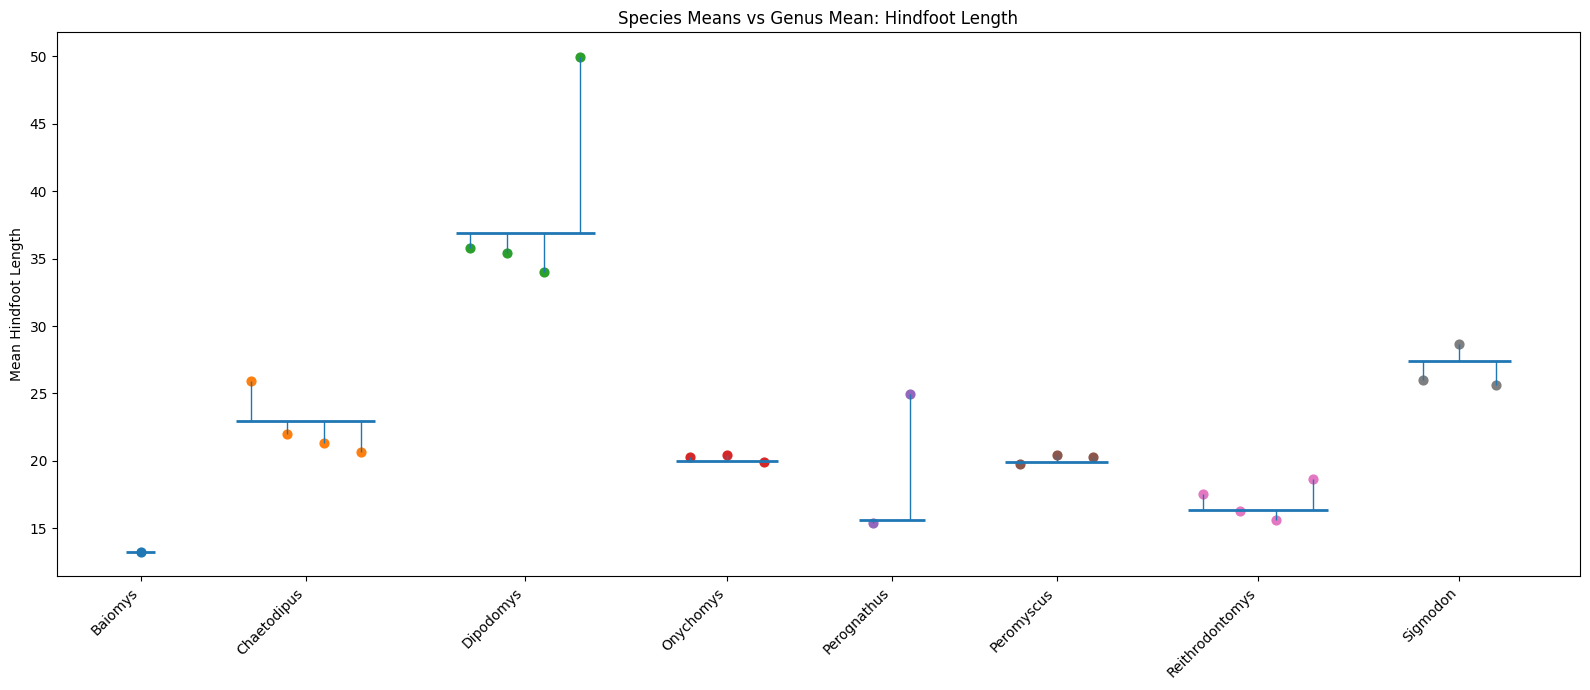

In [13]:
# FIG 1.1

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
analysis_df = df[['genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    analysis_df[col] = analysis_df[col].astype('string').str.strip()

analysis_df = analysis_df.dropna(subset=['genus', 'species_name']).copy()
analysis_df = analysis_df.loc[
    analysis_df['genus'].ne('')
    & analysis_df['species_name'].ne('')
].copy()

species_df = analysis_df.groupby(['species_name', 'genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean')
)

genus_df = analysis_df.groupby(['genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean')
)

# Hindfoot length plot
hindfoot_plot_df = species_df[['genus', 'species_name', 'mean_hindfoot_length']].rename(
    columns={'mean_hindfoot_length': 'species_value'}
).merge(
    genus_df[['genus', 'mean_hindfoot_length']].rename(columns={'mean_hindfoot_length': 'genus_value'}),
    on='genus',
    how='inner'
)

hindfoot_plot_df = hindfoot_plot_df.dropna(subset=['species_value', 'genus_value']).copy()
hindfoot_plot_df = hindfoot_plot_df.sort_values(['genus', 'species_name']).reset_index(drop=True)

genera = hindfoot_plot_df['genus'].drop_duplicates().tolist()
genus_centers = {}
genus_line_ranges = {}
current_x = 0
gap = 2

for genus in genera:
    group = hindfoot_plot_df[hindfoot_plot_df['genus'] == genus].copy()
    n = len(group)
    positions = list(range(current_x, current_x + n))
    genus_centers[genus] = sum(positions) / len(positions)
    genus_line_ranges[genus] = (positions[0] - 0.4, positions[-1] + 0.4)
    hindfoot_plot_df.loc[group.index, 'x'] = positions
    current_x += n + gap

fig, ax = plt.subplots(figsize=(16, 7))

for genus in genera:
    group = hindfoot_plot_df[hindfoot_plot_df['genus'] == genus]
    genus_mean = group['genus_value'].iloc[0]
    x_min, x_max = genus_line_ranges[genus]
    ax.hlines(y=genus_mean, xmin=x_min, xmax=x_max, linewidth=2)

    for _, row in group.iterrows():
        ax.vlines(
            x=row['x'],
            ymin=min(row['species_value'], genus_mean),
            ymax=max(row['species_value'], genus_mean),
            linewidth=1
        )

    ax.scatter(group['x'], group['species_value'], s=40)

ax.set_xticks([genus_centers[g] for g in genera])
ax.set_xticklabels(genera, rotation=45, ha='right')
ax.set_ylabel('Mean Hindfoot Length')
ax.set_title('Species Means vs Genus Mean: Hindfoot Length')
plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_1_1.png", dpi=300, bbox_inches="tight")
plt.show()


### FIG 1.2


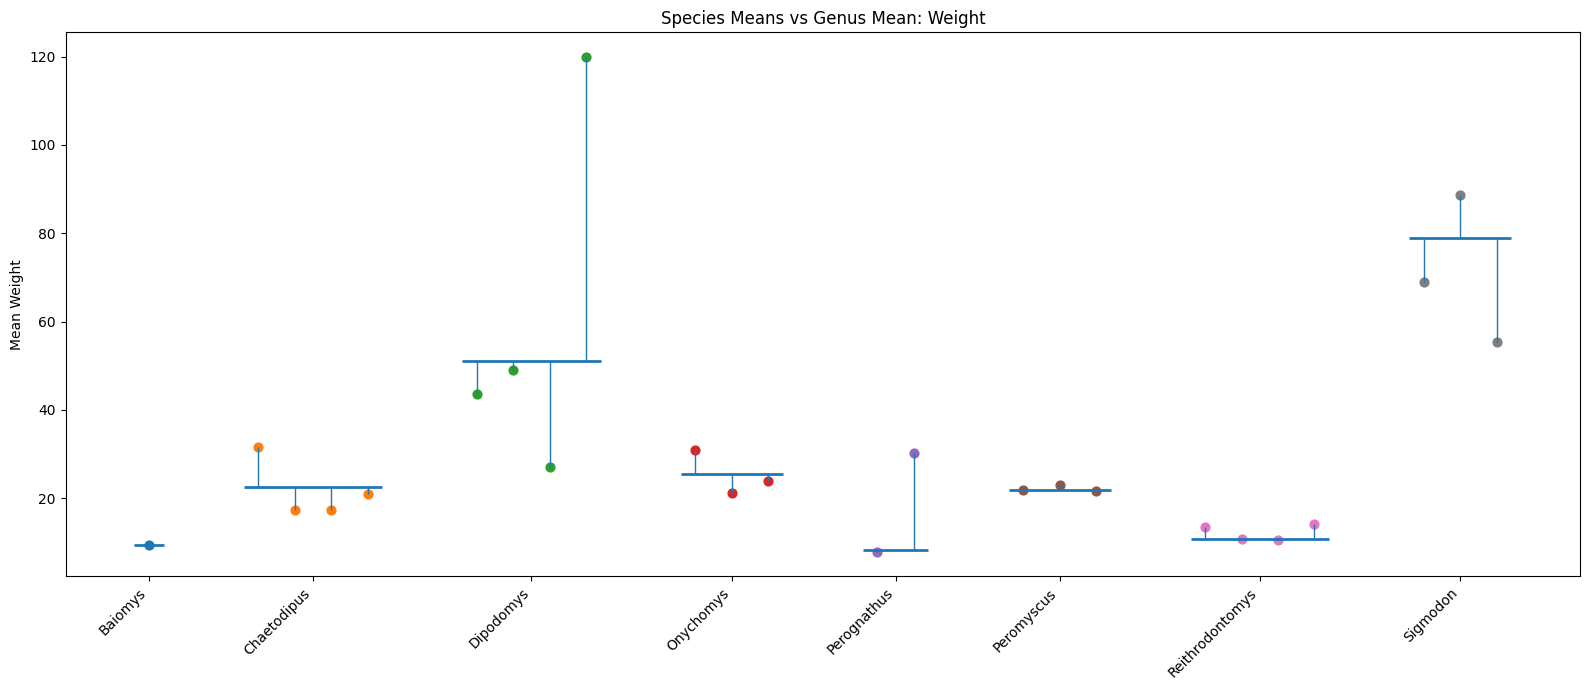

In [14]:
# FIG 1.2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
analysis_df = df[['genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    analysis_df[col] = analysis_df[col].astype('string').str.strip()

analysis_df = analysis_df.dropna(subset=['genus', 'species_name']).copy()
analysis_df = analysis_df.loc[
    analysis_df['genus'].ne('')
    & analysis_df['species_name'].ne('')
].copy()

species_df = analysis_df.groupby(['species_name', 'genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean')
)

genus_df = analysis_df.groupby(['genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean')
)

# Weight plot
weight_plot_df = species_df[['genus', 'species_name', 'mean_weight']].rename(
    columns={'mean_weight': 'species_value'}
).merge(
    genus_df[['genus', 'mean_weight']].rename(columns={'mean_weight': 'genus_value'}),
    on='genus',
    how='inner'
)

weight_plot_df = weight_plot_df.dropna(subset=['species_value', 'genus_value']).copy()
weight_plot_df = weight_plot_df.sort_values(['genus', 'species_name']).reset_index(drop=True)

genera = weight_plot_df['genus'].drop_duplicates().tolist()
genus_centers = {}
genus_line_ranges = {}
current_x = 0
gap = 2

for genus in genera:
    group = weight_plot_df[weight_plot_df['genus'] == genus].copy()
    n = len(group)
    positions = list(range(current_x, current_x + n))
    genus_centers[genus] = sum(positions) / len(positions)
    genus_line_ranges[genus] = (positions[0] - 0.4, positions[-1] + 0.4)
    weight_plot_df.loc[group.index, 'x'] = positions
    current_x += n + gap

fig, ax = plt.subplots(figsize=(16, 7))

for genus in genera:
    group = weight_plot_df[weight_plot_df['genus'] == genus]
    genus_mean = group['genus_value'].iloc[0]
    x_min, x_max = genus_line_ranges[genus]
    ax.hlines(y=genus_mean, xmin=x_min, xmax=x_max, linewidth=2)

    for _, row in group.iterrows():
        ax.vlines(
            x=row['x'],
            ymin=min(row['species_value'], genus_mean),
            ymax=max(row['species_value'], genus_mean),
            linewidth=1
        )

    ax.scatter(group['x'], group['species_value'], s=40)

ax.set_xticks([genus_centers[g] for g in genera])
ax.set_xticklabels(genera, rotation=45, ha='right')
ax.set_ylabel('Mean Weight')
ax.set_title('Species Means vs Genus Mean: Weight')
plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_1_2.png", dpi=300, bbox_inches="tight")
plt.show()


## analysis/aggregation_analysis/monthly_vs_yearly.ipynb


### FIG 2.1


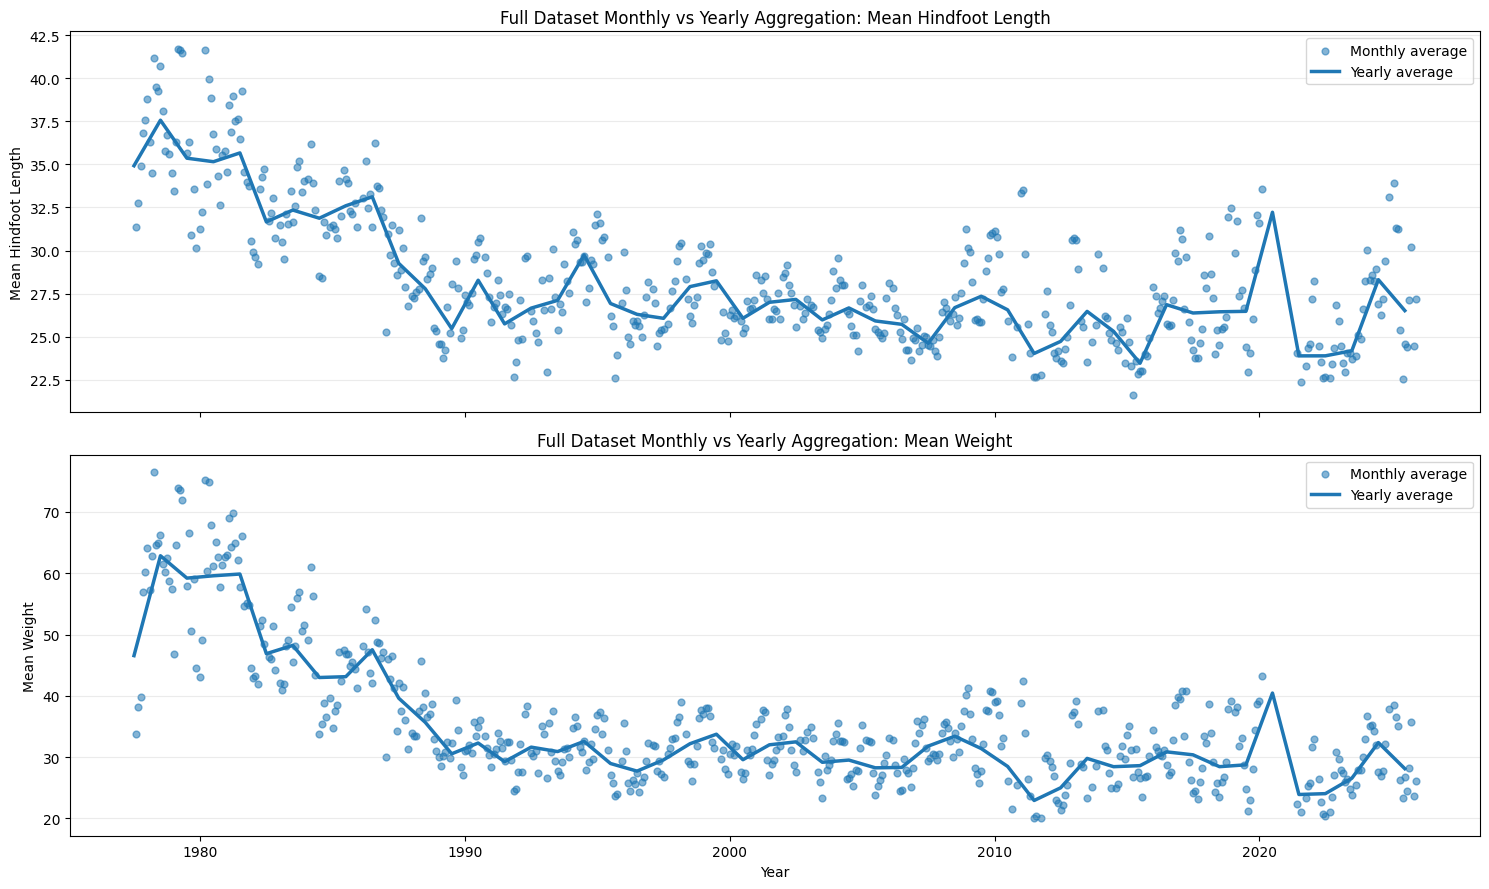

In [15]:
# FIG 2.1

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
time_df = df[['year', 'month', 'genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    time_df[col] = time_df[col].astype('string').str.strip()

time_df = time_df.dropna(subset=['year', 'month', 'genus', 'species_name']).copy()
time_df = time_df.loc[
    time_df['month'].between(1, 12)
    & time_df['genus'].ne('')
    & time_df['species_name'].ne('')
].copy()

time_df['year'] = time_df['year'].astype(int)
time_df['month'] = time_df['month'].astype(int)

monthly_df = (
    time_df.groupby(['year', 'month'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)
monthly_df['date'] = pd.to_datetime(dict(year=monthly_df['year'], month=monthly_df['month'], day=1))

yearly_df = (
    time_df.groupby(['year'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)
yearly_df['date'] = pd.to_datetime(dict(year=yearly_df['year'], month=7, day=1))

def plot_monthly_scatter_with_yearly_line(monthly_data, yearly_data, title_prefix):
    metrics = [
        ('mean_hindfoot_length', 'Mean Hindfoot Length'),
        ('mean_weight', 'Mean Weight'),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

    for ax, (metric, ylabel) in zip(axes, metrics):
        clean_monthly = monthly_data.dropna(subset=[metric]).sort_values('date')
        clean_yearly = yearly_data.dropna(subset=[metric]).sort_values('date')

        ax.scatter(clean_monthly['date'], clean_monthly[metric], s=24, alpha=0.55, label='Monthly average')
        ax.plot(clean_yearly['date'], clean_yearly[metric], linewidth=2.5, label='Yearly average')
        ax.set_title(f'{title_prefix}: {ylabel}')
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25)
        ax.legend()

    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    fig.savefig(IMAGES_DIR / "fig_2_1.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_monthly_scatter_with_yearly_line(
    monthly_df,
    yearly_df,
    'Full Dataset Monthly vs Yearly Aggregation'
)


### FIG 2.2


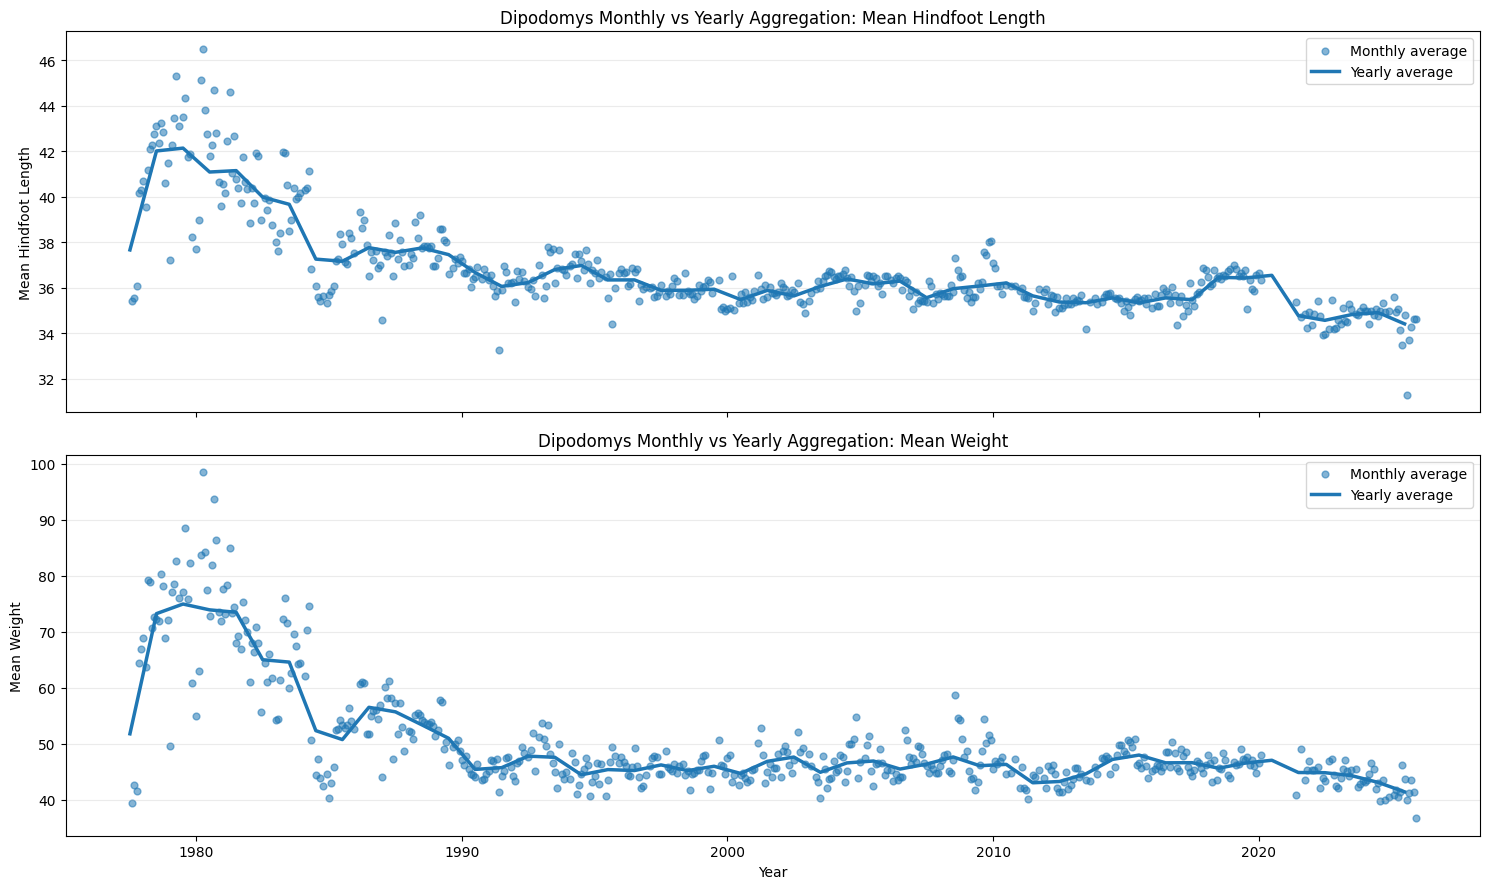

In [16]:
# FIG 2.2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
time_df = df[['year', 'month', 'genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    time_df[col] = time_df[col].astype('string').str.strip()

time_df = time_df.dropna(subset=['year', 'month', 'genus', 'species_name']).copy()
time_df = time_df.loc[
    time_df['month'].between(1, 12)
    & time_df['genus'].ne('')
    & time_df['species_name'].ne('')
].copy()

time_df['year'] = time_df['year'].astype(int)
time_df['month'] = time_df['month'].astype(int)

def plot_monthly_scatter_with_yearly_line(monthly_data, yearly_data, title_prefix):
    metrics = [
        ('mean_hindfoot_length', 'Mean Hindfoot Length'),
        ('mean_weight', 'Mean Weight'),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

    for ax, (metric, ylabel) in zip(axes, metrics):
        clean_monthly = monthly_data.dropna(subset=[metric]).sort_values('date')
        clean_yearly = yearly_data.dropna(subset=[metric]).sort_values('date')

        ax.scatter(clean_monthly['date'], clean_monthly[metric], s=24, alpha=0.55, label='Monthly average')
        ax.plot(clean_yearly['date'], clean_yearly[metric], linewidth=2.5, label='Yearly average')
        ax.set_title(f'{title_prefix}: {ylabel}')
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25)
        ax.legend()

    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    fig.savefig(IMAGES_DIR / "fig_2_2.png", dpi=300, bbox_inches="tight")
    plt.show()

dipodomys_df = time_df.loc[time_df['genus'] == 'Dipodomys'].copy()

dipodomys_monthly_df = (
    dipodomys_df.groupby(['year', 'month'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)
dipodomys_monthly_df['date'] = pd.to_datetime(dict(year=dipodomys_monthly_df['year'], month=dipodomys_monthly_df['month'], day=1))

dipodomys_yearly_df = (
    dipodomys_df.groupby(['year'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)
dipodomys_yearly_df['date'] = pd.to_datetime(dict(year=dipodomys_yearly_df['year'], month=7, day=1))

plot_monthly_scatter_with_yearly_line(
    dipodomys_monthly_df,
    dipodomys_yearly_df,
    'Dipodomys Monthly vs Yearly Aggregation'
)


### FIG 2.3


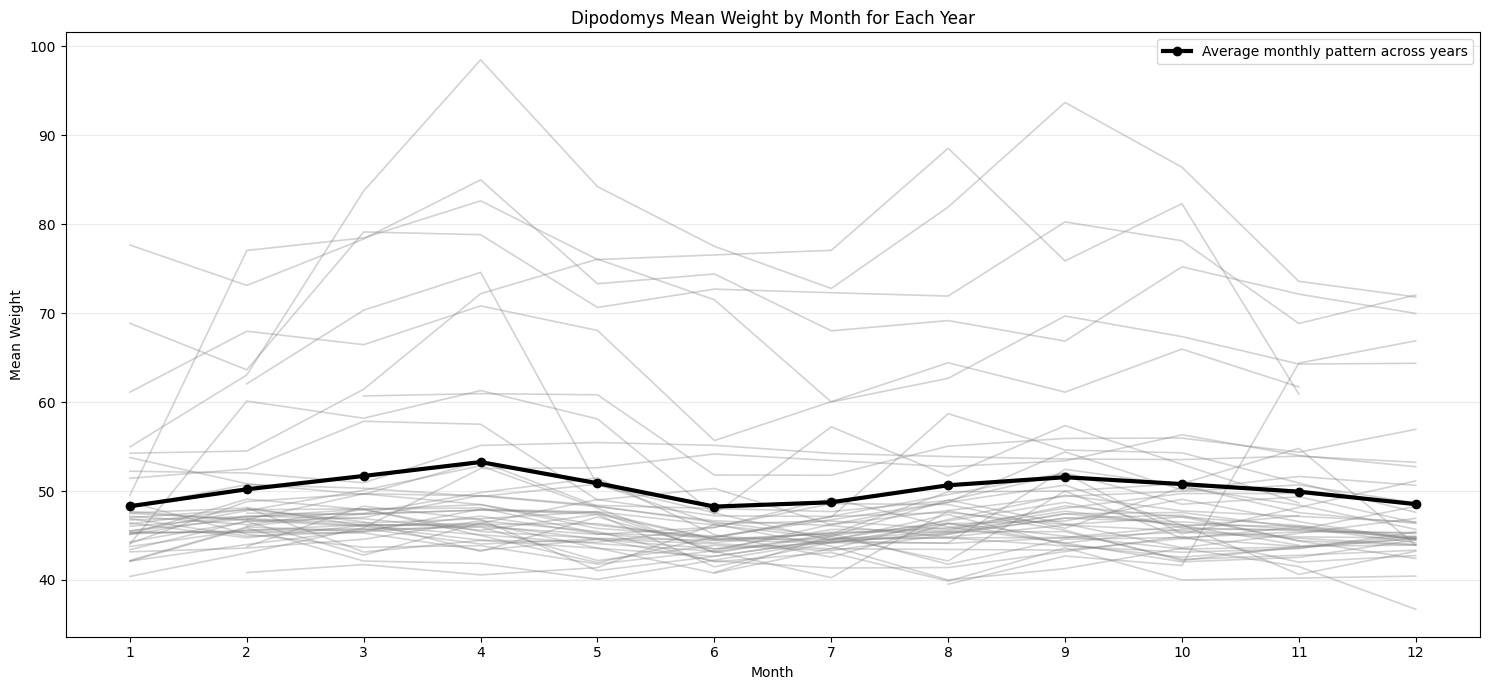

In [17]:
# FIG 2.3

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
time_df = df[['year', 'month', 'genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    time_df[col] = time_df[col].astype('string').str.strip()

time_df = time_df.dropna(subset=['year', 'month', 'genus', 'species_name']).copy()
time_df = time_df.loc[
    time_df['month'].between(1, 12)
    & time_df['genus'].ne('')
    & time_df['species_name'].ne('')
].copy()

time_df['year'] = time_df['year'].astype(int)
time_df['month'] = time_df['month'].astype(int)

dipodomys_df = time_df.loc[time_df['genus'] == 'Dipodomys'].copy()
dipodomys_monthly_df = (
    dipodomys_df.groupby(['year', 'month'], as_index=False)
    .agg(
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        mean_weight=('weight', 'mean'),
        n_observations=('weight', 'size'),
    )
)
dipodomys_monthly_df['date'] = pd.to_datetime(dict(year=dipodomys_monthly_df['year'], month=dipodomys_monthly_df['month'], day=1))

dipodomys_year_month_weight = dipodomys_monthly_df.dropna(subset=['mean_weight']).copy()
pivot_weight = dipodomys_year_month_weight.pivot(index='month', columns='year', values='mean_weight')

fig, ax = plt.subplots(figsize=(15, 7))

for year in pivot_weight.columns:
    yearly_values = pivot_weight[year].dropna()
    if len(yearly_values) >= 3:
        ax.plot(yearly_values.index, yearly_values.values, linewidth=1.2, alpha=0.35, color='gray')

monthly_pattern = dipodomys_year_month_weight.groupby('month', as_index=False).agg(mean_weight=('mean_weight', 'mean'))

ax.plot(
    monthly_pattern['month'],
    monthly_pattern['mean_weight'],
    linewidth=3,
    color='black',
    marker='o',
    label='Average monthly pattern across years'
)

ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Mean Weight')
ax.set_title('Dipodomys Mean Weight by Month for Each Year')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_2_3.png", dpi=300, bbox_inches="tight")
plt.show()


## analysis/aggregation_analysis/mean_vs_median_weight.ipynb


### FIG 3.1


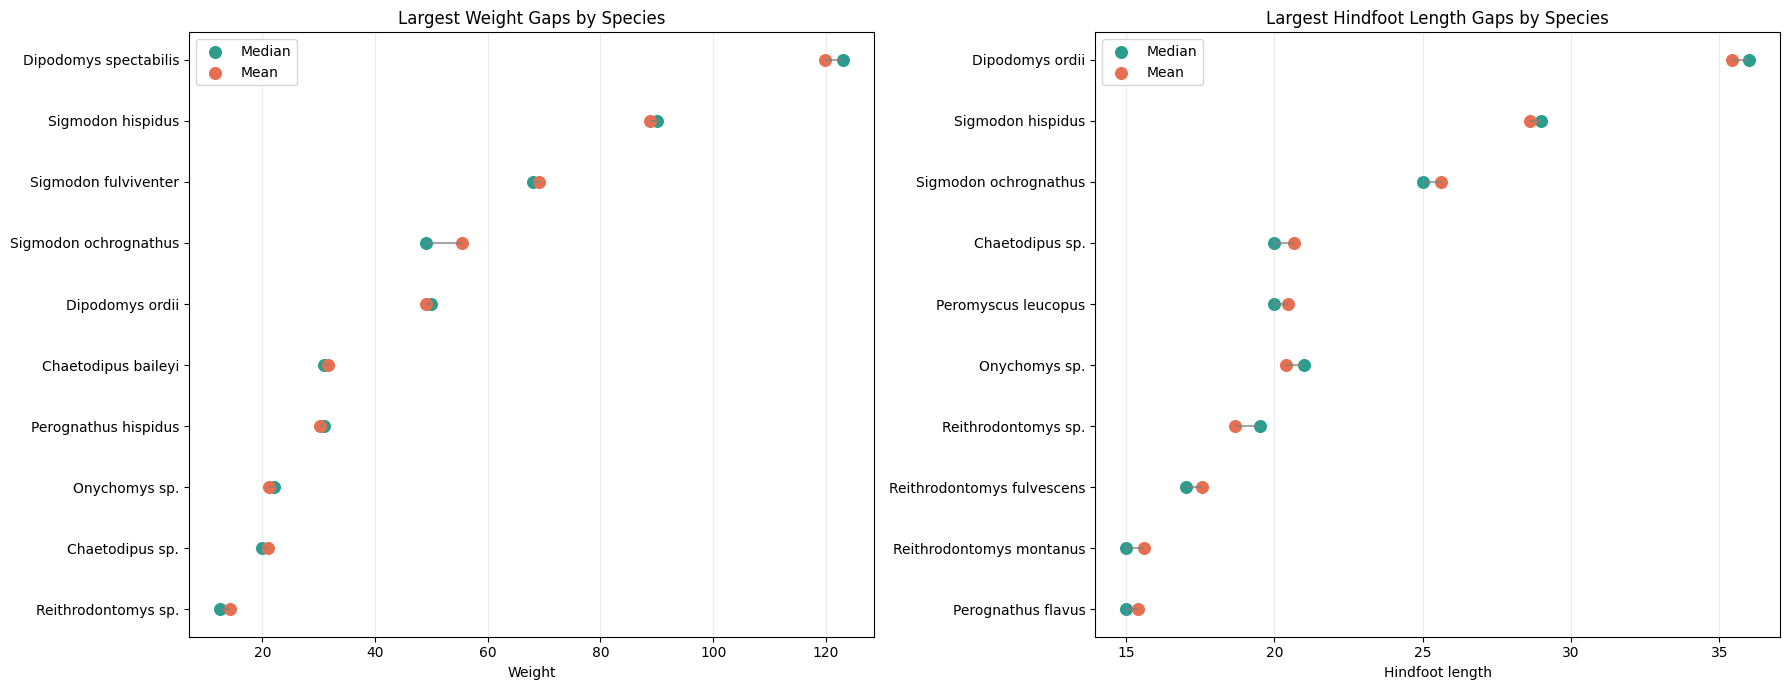

In [18]:
# FIG 3.1

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
measure_df = df[['year', 'month', 'genus', 'species_name', 'taxa', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name', 'taxa']:
    measure_df[col] = measure_df[col].astype('string').str.strip()

measure_df = measure_df.dropna(subset=['year', 'month', 'genus', 'species_name', 'taxa']).copy()
measure_df = measure_df.loc[
    measure_df['genus'].ne('')
    & measure_df['species_name'].ne('')
    & measure_df['taxa'].ne('')
].copy()

measure_df.loc[measure_df['hindfoot_length'] <= 0, 'hindfoot_length'] = pd.NA
measure_df.loc[measure_df['weight'] <= 0, 'weight'] = pd.NA

def summarize_mean_median(data, group_cols):
    summary = (
        data.groupby(group_cols, as_index=False)
        .agg(
            n_hindfoot=('hindfoot_length', 'count'),
            mean_hindfoot_length=('hindfoot_length', 'mean'),
            median_hindfoot_length=('hindfoot_length', 'median'),
            n_weight=('weight', 'count'),
            mean_weight=('weight', 'mean'),
            median_weight=('weight', 'median'),
        )
    )

    summary['hindfoot_gap'] = summary['mean_hindfoot_length'] - summary['median_hindfoot_length']
    summary['weight_gap'] = summary['mean_weight'] - summary['median_weight']
    summary['hindfoot_percent_gap'] = summary['hindfoot_gap'] / summary['median_hindfoot_length'] * 100
    summary['weight_percent_gap'] = summary['weight_gap'] / summary['median_weight'] * 100

    return summary.round(2)

species_summary_df = summarize_mean_median(measure_df, ['genus', 'species_name'])

top_weight_species = (
    species_summary_df.dropna(subset=['mean_weight', 'median_weight'])
    .assign(abs_gap=lambda data: data['weight_gap'].abs())
    .sort_values('abs_gap', ascending=False)
    .head(10)
    .sort_values('mean_weight')
)

top_hindfoot_species = (
    species_summary_df.dropna(subset=['mean_hindfoot_length', 'median_hindfoot_length'])
    .assign(abs_gap=lambda data: data['hindfoot_gap'].abs())
    .sort_values('abs_gap', ascending=False)
    .head(10)
    .sort_values('mean_hindfoot_length')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, plot_df, mean_col, median_col, title, xlabel in [
    (axes[0], top_weight_species, 'mean_weight', 'median_weight', 'Largest Weight Gaps by Species', 'Weight'),
    (axes[1], top_hindfoot_species, 'mean_hindfoot_length', 'median_hindfoot_length', 'Largest Hindfoot Length Gaps by Species', 'Hindfoot length'),
]:
    labels = plot_df['genus'] + ' ' + plot_df['species_name']
    y_positions = range(len(plot_df))

    ax.hlines(y=y_positions, xmin=plot_df[median_col], xmax=plot_df[mean_col], color='gray', alpha=0.7)
    ax.scatter(plot_df[median_col], y_positions, label='Median', color='#2a9d8f', s=70)
    ax.scatter(plot_df[mean_col], y_positions, label='Mean', color='#e76f51', s=70)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', alpha=0.25)
    ax.legend()

plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_3_1.png", dpi=300, bbox_inches="tight")
plt.show()


### FIG 3.2


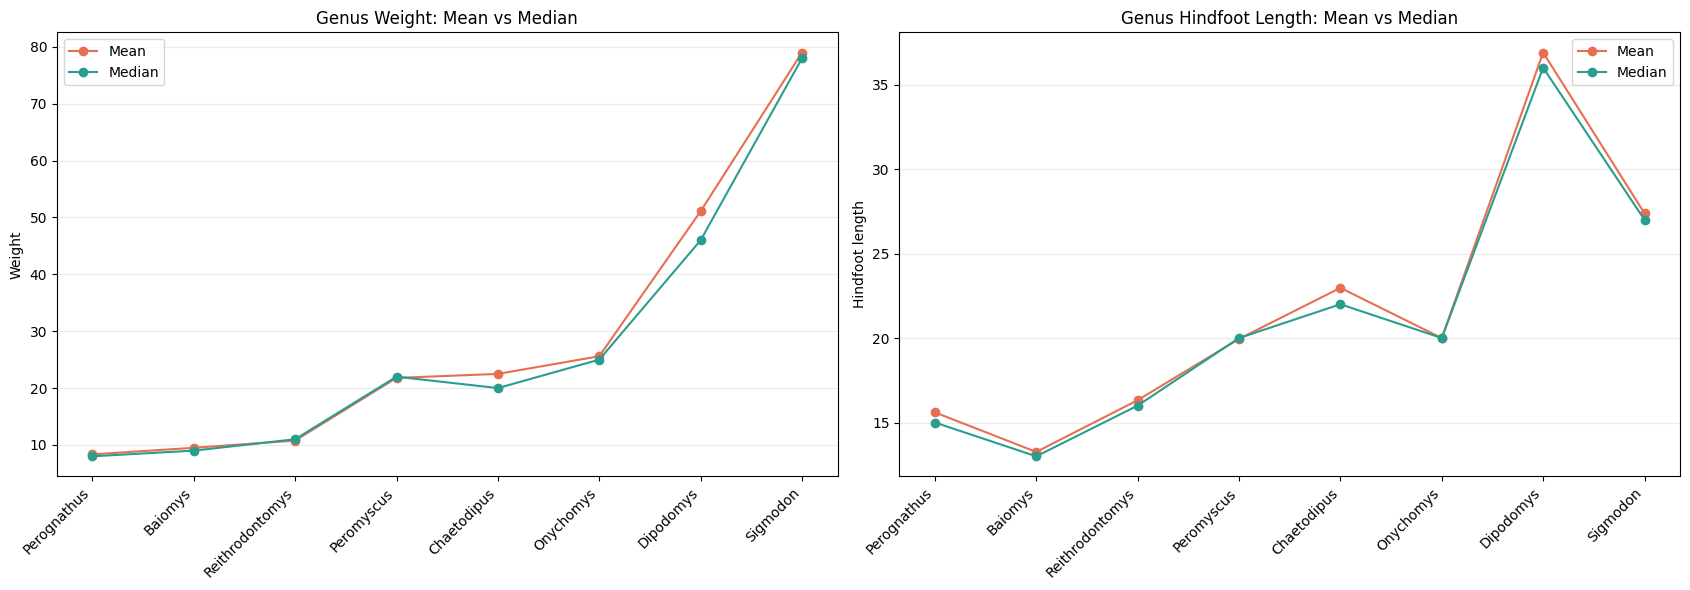

In [19]:
# FIG 3.2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
measure_df = df[['year', 'month', 'genus', 'species_name', 'taxa', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name', 'taxa']:
    measure_df[col] = measure_df[col].astype('string').str.strip()

measure_df = measure_df.dropna(subset=['year', 'month', 'genus', 'species_name', 'taxa']).copy()
measure_df = measure_df.loc[
    measure_df['genus'].ne('')
    & measure_df['species_name'].ne('')
    & measure_df['taxa'].ne('')
].copy()

measure_df.loc[measure_df['hindfoot_length'] <= 0, 'hindfoot_length'] = pd.NA
measure_df.loc[measure_df['weight'] <= 0, 'weight'] = pd.NA

def summarize_mean_median(data, group_cols):
    summary = (
        data.groupby(group_cols, as_index=False)
        .agg(
            n_hindfoot=('hindfoot_length', 'count'),
            mean_hindfoot_length=('hindfoot_length', 'mean'),
            median_hindfoot_length=('hindfoot_length', 'median'),
            n_weight=('weight', 'count'),
            mean_weight=('weight', 'mean'),
            median_weight=('weight', 'median'),
        )
    )

    summary['hindfoot_gap'] = summary['mean_hindfoot_length'] - summary['median_hindfoot_length']
    summary['weight_gap'] = summary['mean_weight'] - summary['median_weight']
    summary['hindfoot_percent_gap'] = summary['hindfoot_gap'] / summary['median_hindfoot_length'] * 100
    summary['weight_percent_gap'] = summary['weight_gap'] / summary['median_weight'] * 100

    return summary.round(2)

genus_summary_df = summarize_mean_median(measure_df, ['genus'])
genus_plot_df = genus_summary_df.sort_values('mean_weight').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, mean_col, median_col, title, ylabel in [
    (axes[0], 'mean_weight', 'median_weight', 'Genus Weight: Mean vs Median', 'Weight'),
    (axes[1], 'mean_hindfoot_length', 'median_hindfoot_length', 'Genus Hindfoot Length: Mean vs Median', 'Hindfoot length'),
]:
    x_positions = range(len(genus_plot_df))
    ax.plot(x_positions, genus_plot_df[mean_col], marker='o', label='Mean', color='#e76f51')
    ax.plot(x_positions, genus_plot_df[median_col], marker='o', label='Median', color='#2a9d8f')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(genus_plot_df['genus'], rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_3_2.png", dpi=300, bbox_inches="tight")
plt.show()


### FIG 3.3


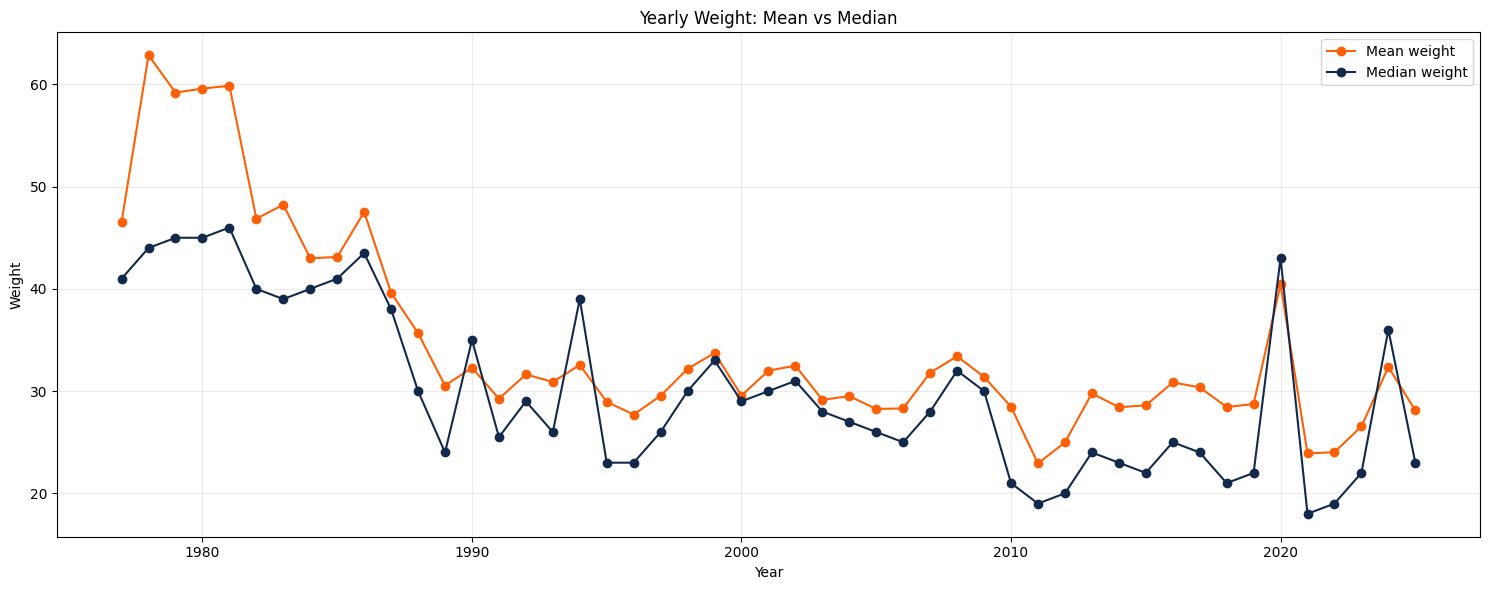

In [20]:
# FIG 3.3

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
measure_df = df[['year', 'month', 'genus', 'species_name', 'taxa', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name', 'taxa']:
    measure_df[col] = measure_df[col].astype('string').str.strip()

measure_df = measure_df.dropna(subset=['year', 'month', 'genus', 'species_name', 'taxa']).copy()
measure_df = measure_df.loc[
    measure_df['genus'].ne('')
    & measure_df['species_name'].ne('')
    & measure_df['taxa'].ne('')
].copy()

measure_df.loc[measure_df['hindfoot_length'] <= 0, 'hindfoot_length'] = pd.NA
measure_df.loc[measure_df['weight'] <= 0, 'weight'] = pd.NA

def summarize_mean_median(data, group_cols):
    summary = (
        data.groupby(group_cols, as_index=False)
        .agg(
            n_hindfoot=('hindfoot_length', 'count'),
            mean_hindfoot_length=('hindfoot_length', 'mean'),
            median_hindfoot_length=('hindfoot_length', 'median'),
            n_weight=('weight', 'count'),
            mean_weight=('weight', 'mean'),
            median_weight=('weight', 'median'),
        )
    )

    summary['hindfoot_gap'] = summary['mean_hindfoot_length'] - summary['median_hindfoot_length']
    summary['weight_gap'] = summary['mean_weight'] - summary['median_weight']
    summary['hindfoot_percent_gap'] = summary['hindfoot_gap'] / summary['median_hindfoot_length'] * 100
    summary['weight_percent_gap'] = summary['weight_gap'] / summary['median_weight'] * 100

    return summary.round(2)

yearly_summary_df = summarize_mean_median(measure_df, ['year'])

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(yearly_summary_df['year'], yearly_summary_df['mean_weight'], marker='o', label='Mean weight', color='#FF5F05')
ax.plot(yearly_summary_df['year'], yearly_summary_df['median_weight'], marker='o', label='Median weight', color='#13294B')

ax.set_title('Yearly Weight: Mean vs Median')
ax.set_xlabel('Year')
ax.set_ylabel('Weight')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_3_3.png", dpi=300, bbox_inches="tight")
plt.show()


## analysis/sampling_bias/stratified_sampling.ipynb


### FIG 4.1


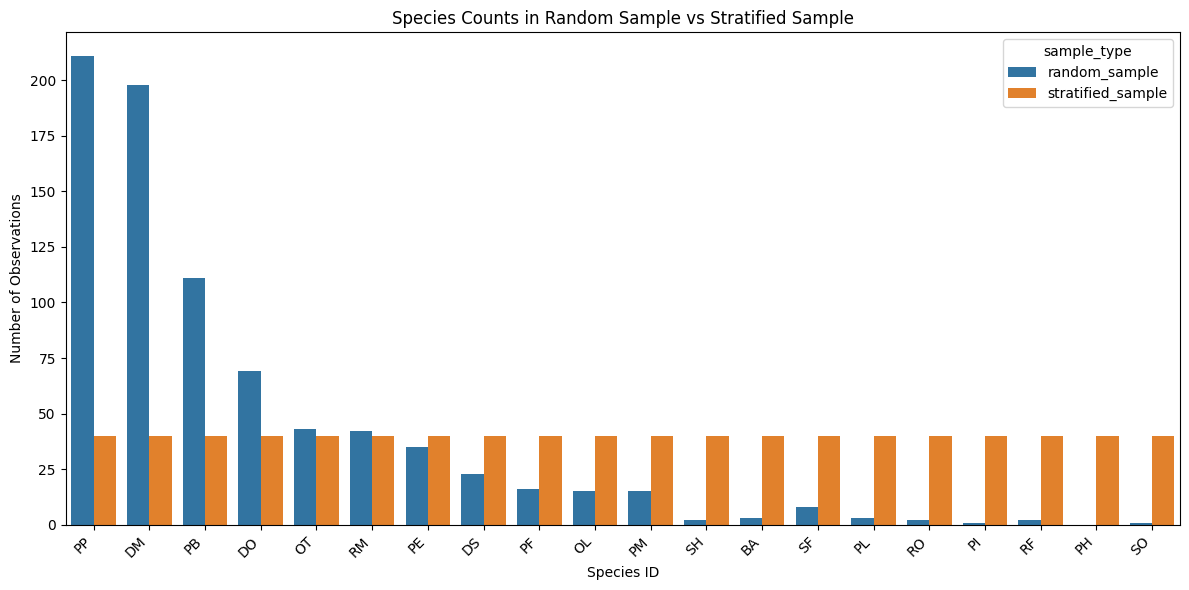

In [21]:
# FIG 4.1

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)
import seaborn as sns

RANDOM_SEED = 123
OBSERVATIONS_PER_SPECIES = 40

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
sample_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'genus',
    'taxa',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'genus', 'taxa', 'plot_type']:
    sample_df[col] = sample_df[col].astype('string').str.strip()

sample_df = sample_df.dropna(subset=['species_id', 'species_name']).copy()

species_counts = (
    sample_df.groupby(['species_id', 'species_name'], as_index=False)
    .size()
    .rename(columns={'size': 'full_dataset_count'})
    .sort_values('full_dataset_count', ascending=False)
)
species_counts['full_dataset_percent'] = species_counts['full_dataset_count'] / species_counts['full_dataset_count'].sum()

eligible_species = species_counts.loc[
    species_counts['full_dataset_count'] >= OBSERVATIONS_PER_SPECIES,
    'species_id'
]
sampling_frame = sample_df[sample_df['species_id'].isin(eligible_species)].copy()
n_species = sampling_frame['species_id'].nunique()
total_sample_size = n_species * OBSERVATIONS_PER_SPECIES

random_sample = sampling_frame.sample(n=total_sample_size, random_state=RANDOM_SEED).reset_index(drop=True)
stratified_sample = (
    sampling_frame
    .groupby('species_id', group_keys=False)
    .sample(n=OBSERVATIONS_PER_SPECIES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

representation_df = pd.DataFrame({
    'full_dataset_count': sampling_frame['species_id'].value_counts(),
    'random_sample_count': random_sample['species_id'].value_counts(),
    'stratified_sample_count': stratified_sample['species_id'].value_counts(),
    'full_dataset_percent': sampling_frame['species_id'].value_counts(normalize=True),
    'random_sample_percent': random_sample['species_id'].value_counts(normalize=True),
    'stratified_sample_percent': stratified_sample['species_id'].value_counts(normalize=True)
}).fillna(0)

count_columns = ['full_dataset_count', 'random_sample_count', 'stratified_sample_count']
representation_df[count_columns] = representation_df[count_columns].astype(int)
representation_df = representation_df.sort_values('full_dataset_count', ascending=False)

sample_counts = (
    representation_df[['random_sample_count', 'stratified_sample_count']]
    .reset_index(names='species_id')
    .melt(id_vars='species_id', var_name='sample_type', value_name='n_observations')
)
sample_counts['sample_type'] = sample_counts['sample_type'].str.replace('_count', '', regex=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=sample_counts, x='species_id', y='n_observations', hue='sample_type')
plt.xticks(rotation=45, ha='right')
plt.title('Species Counts in Random Sample vs Stratified Sample')
plt.xlabel('Species ID')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.savefig(IMAGES_DIR / "fig_4_1.png", dpi=300, bbox_inches="tight")
plt.show()


### FIG 4.2


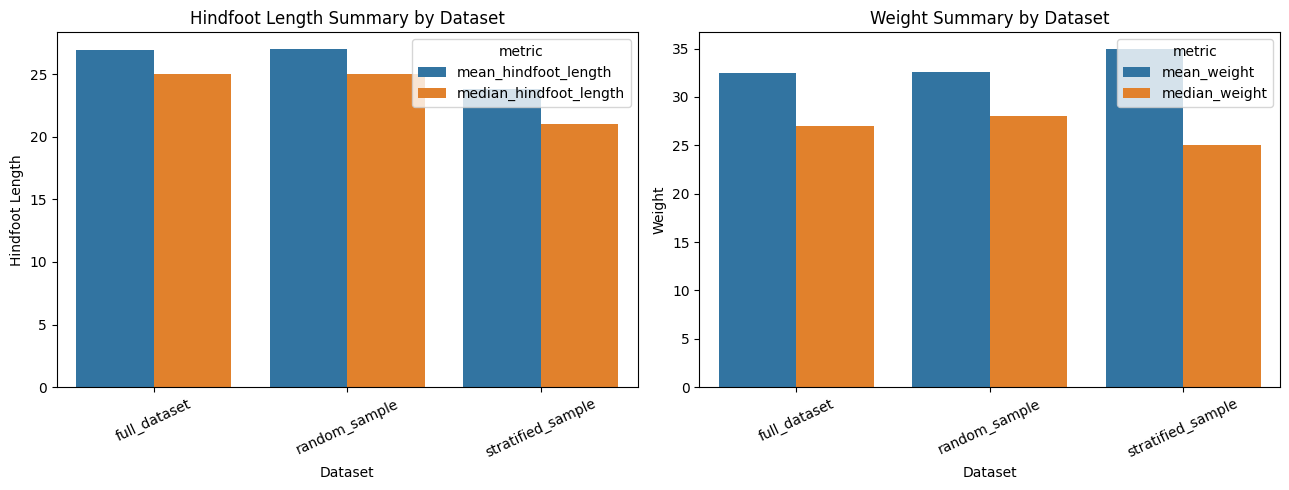

In [22]:
# FIG 4.2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)
import seaborn as sns

RANDOM_SEED = 123
OBSERVATIONS_PER_SPECIES = 40

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
sample_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'genus',
    'taxa',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'genus', 'taxa', 'plot_type']:
    sample_df[col] = sample_df[col].astype('string').str.strip()

sample_df = sample_df.dropna(subset=['species_id', 'species_name']).copy()

species_counts = (
    sample_df.groupby(['species_id', 'species_name'], as_index=False)
    .size()
    .rename(columns={'size': 'full_dataset_count'})
    .sort_values('full_dataset_count', ascending=False)
)
species_counts['full_dataset_percent'] = species_counts['full_dataset_count'] / species_counts['full_dataset_count'].sum()

eligible_species = species_counts.loc[
    species_counts['full_dataset_count'] >= OBSERVATIONS_PER_SPECIES,
    'species_id'
]
sampling_frame = sample_df[sample_df['species_id'].isin(eligible_species)].copy()
n_species = sampling_frame['species_id'].nunique()
total_sample_size = n_species * OBSERVATIONS_PER_SPECIES

random_sample = sampling_frame.sample(n=total_sample_size, random_state=RANDOM_SEED).reset_index(drop=True)
stratified_sample = (
    sampling_frame
    .groupby('species_id', group_keys=False)
    .sample(n=OBSERVATIONS_PER_SPECIES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

representation_df = pd.DataFrame({
    'full_dataset_count': sampling_frame['species_id'].value_counts(),
    'random_sample_count': random_sample['species_id'].value_counts(),
    'stratified_sample_count': stratified_sample['species_id'].value_counts(),
    'full_dataset_percent': sampling_frame['species_id'].value_counts(normalize=True),
    'random_sample_percent': random_sample['species_id'].value_counts(normalize=True),
    'stratified_sample_percent': stratified_sample['species_id'].value_counts(normalize=True)
}).fillna(0)

count_columns = ['full_dataset_count', 'random_sample_count', 'stratified_sample_count']
representation_df[count_columns] = representation_df[count_columns].astype(int)
representation_df = representation_df.sort_values('full_dataset_count', ascending=False)

summary_df = pd.DataFrame({
    'dataset': ['full_dataset', 'random_sample', 'stratified_sample'],
    'number_observations': [len(sampling_frame), len(random_sample), len(stratified_sample)],
    'number_species': [
        sampling_frame['species_id'].nunique(),
        random_sample['species_id'].nunique(),
        stratified_sample['species_id'].nunique()
    ],
    'mean_hindfoot_length': [
        sampling_frame['hindfoot_length'].mean(),
        random_sample['hindfoot_length'].mean(),
        stratified_sample['hindfoot_length'].mean()
    ],
    'median_hindfoot_length': [
        sampling_frame['hindfoot_length'].median(),
        random_sample['hindfoot_length'].median(),
        stratified_sample['hindfoot_length'].median()
    ],
    'mean_weight': [
        sampling_frame['weight'].mean(),
        random_sample['weight'].mean(),
        stratified_sample['weight'].mean()
    ],
    'median_weight': [
        sampling_frame['weight'].median(),
        random_sample['weight'].median(),
        stratified_sample['weight'].median()
    ]
})

summary_plot_df = summary_df.melt(
    id_vars='dataset',
    value_vars=['mean_hindfoot_length', 'median_hindfoot_length', 'mean_weight', 'median_weight'],
    var_name='metric',
    value_name='value'
)

hindfoot_plot_df = summary_plot_df[summary_plot_df['metric'].isin(['mean_hindfoot_length', 'median_hindfoot_length'])].copy()
weight_plot_df = summary_plot_df[summary_plot_df['metric'].isin(['mean_weight', 'median_weight'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=hindfoot_plot_df, x='dataset', y='value', hue='metric', ax=axes[0])
axes[0].set_title('Hindfoot Length Summary by Dataset')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Hindfoot Length')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=weight_plot_df, x='dataset', y='value', hue='metric', ax=axes[1])
axes[1].set_title('Weight Summary by Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Weight')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(IMAGES_DIR / "fig_4_2.png", dpi=300, bbox_inches="tight")
plt.show()


### FIG 4.3


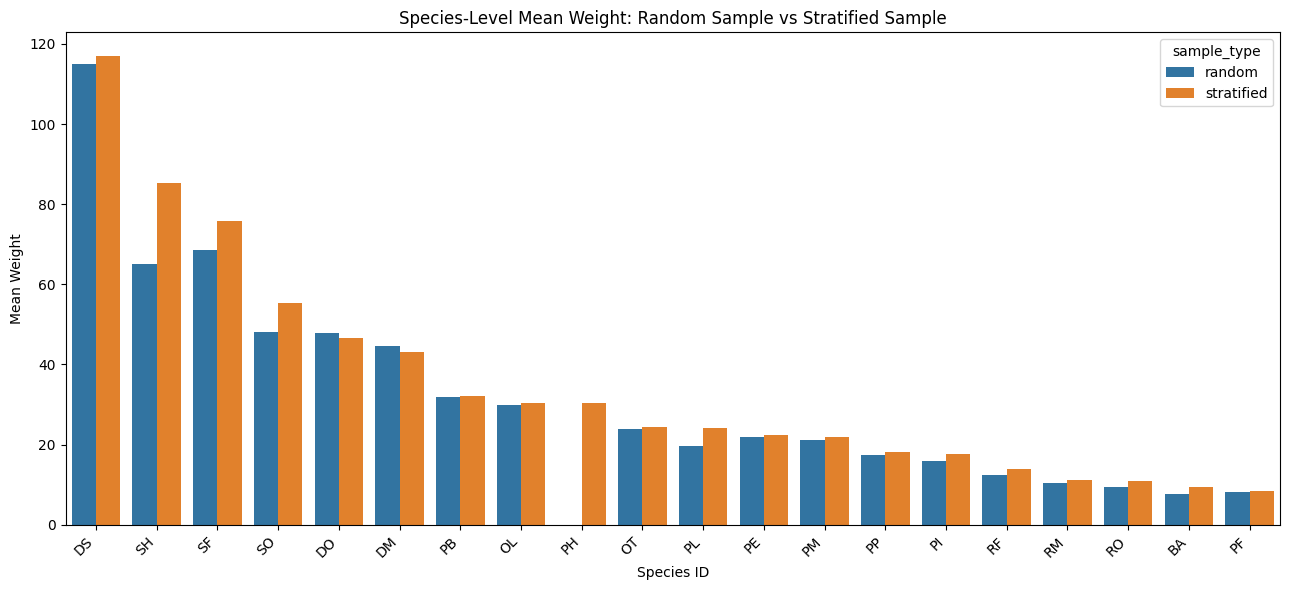

In [23]:
# FIG 4.3

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)
import seaborn as sns

RANDOM_SEED = 123
OBSERVATIONS_PER_SPECIES = 40

# Load and prepare data
df = pd.read_csv("output/merged_full.csv")
sample_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'genus',
    'taxa',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'genus', 'taxa', 'plot_type']:
    sample_df[col] = sample_df[col].astype('string').str.strip()

sample_df = sample_df.dropna(subset=['species_id', 'species_name']).copy()

species_counts = (
    sample_df.groupby(['species_id', 'species_name'], as_index=False)
    .size()
    .rename(columns={'size': 'full_dataset_count'})
    .sort_values('full_dataset_count', ascending=False)
)
species_counts['full_dataset_percent'] = species_counts['full_dataset_count'] / species_counts['full_dataset_count'].sum()

eligible_species = species_counts.loc[
    species_counts['full_dataset_count'] >= OBSERVATIONS_PER_SPECIES,
    'species_id'
]
sampling_frame = sample_df[sample_df['species_id'].isin(eligible_species)].copy()
n_species = sampling_frame['species_id'].nunique()
total_sample_size = n_species * OBSERVATIONS_PER_SPECIES

random_sample = sampling_frame.sample(n=total_sample_size, random_state=RANDOM_SEED).reset_index(drop=True)
stratified_sample = (
    sampling_frame
    .groupby('species_id', group_keys=False)
    .sample(n=OBSERVATIONS_PER_SPECIES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

representation_df = pd.DataFrame({
    'full_dataset_count': sampling_frame['species_id'].value_counts(),
    'random_sample_count': random_sample['species_id'].value_counts(),
    'stratified_sample_count': stratified_sample['species_id'].value_counts(),
    'full_dataset_percent': sampling_frame['species_id'].value_counts(normalize=True),
    'random_sample_percent': random_sample['species_id'].value_counts(normalize=True),
    'stratified_sample_percent': stratified_sample['species_id'].value_counts(normalize=True)
}).fillna(0)

count_columns = ['full_dataset_count', 'random_sample_count', 'stratified_sample_count']
representation_df[count_columns] = representation_df[count_columns].astype(int)
representation_df = representation_df.sort_values('full_dataset_count', ascending=False)

random_species_summary = (
    random_sample.groupby('species_id')
    .agg(random_number=('weight', 'size'), random_mean_weight=('weight', 'mean'))
)

stratified_species_summary = (
    stratified_sample.groupby('species_id')
    .agg(stratified_number=('weight', 'size'), stratified_mean_weight=('weight', 'mean'))
)

species_level_comparison = random_species_summary.join(stratified_species_summary, how='outer')
species_level_comparison = species_level_comparison[
    ['random_number', 'stratified_number', 'random_mean_weight', 'stratified_mean_weight']
]

species_weight_plot_df = (
    species_level_comparison
    .reset_index()
    .sort_values('stratified_mean_weight', ascending=False)
    .melt(
        id_vars='species_id',
        value_vars=['random_mean_weight', 'stratified_mean_weight'],
        var_name='sample_type',
        value_name='mean_weight'
    )
)

species_weight_plot_df['sample_type'] = (
    species_weight_plot_df['sample_type']
    .str.replace('_mean_weight', '', regex=False)
    .str.replace('_', ' ', regex=False)
)

plt.figure(figsize=(13, 6))
sns.barplot(data=species_weight_plot_df, x='species_id', y='mean_weight', hue='sample_type')
plt.xticks(rotation=45, ha='right')
plt.title('Species-Level Mean Weight: Random Sample vs Stratified Sample')
plt.xlabel('Species ID')
plt.ylabel('Mean Weight')
plt.tight_layout()
plt.savefig(IMAGES_DIR / "fig_4_3.png", dpi=300, bbox_inches="tight")
plt.show()
